<a href="https://colab.research.google.com/github/fadeeva/portfoli_o_o_ptimisation/blob/main/Step_02__Classical_Markowitz%20_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from scipy import optimize

import datetime as dt
import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
rng = np.random.default_rng(42)

# Classical Markowitz optimization

In [3]:
tickers  = ['AMD', 'AMZN', 'BAC', 'META', 'AVGO', 'TER', 'NVDA']

df = yf.download(tickers, dt.datetime(2022, 1, 1), dt.datetime.now(), auto_adjust=True)
df = df['Close']
df = pd.concat([df, df.pct_change().add_suffix('_simp_ret')], axis=1)
df.dropna(inplace=True)

df.head()

[*********************100%***********************]  7 of 7 completed


Ticker,AMD,AMZN,AVGO,BAC,META,NVDA,TER,AMD_simp_ret,AMZN_simp_ret,AVGO_simp_ret,BAC_simp_ret,META_simp_ret,NVDA_simp_ret,TER_simp_ret
Date,,,,,,,,,,,,,,
2022-01-04,144.419998,167.522003,62.018639,42.882717,333.600464,29.197762,163.409286,-0.038738,-0.016916,0.011458,0.039194,-0.005937,-0.027589,0.001626
2022-01-05,136.149994,164.356995,59.437756,42.158924,321.348083,27.517076,157.388733,-0.057264,-0.018893,-0.041615,-0.016878,-0.036728,-0.057562,-0.036843
2022-01-06,136.229996,163.253998,58.885895,43.007820,329.565948,28.089262,160.561066,0.000588,-0.006711,-0.009285,0.020136,0.025573,0.020794,0.020156
2022-01-07,132.000000,162.554001,57.233105,43.946068,328.901703,27.161194,155.444122,-0.031050,-0.004288,-0.028068,0.021816,-0.002016,-0.033040,-0.031869
2022-01-10,132.000000,161.485992,57.418903,43.722687,325.214081,27.313715,153.813721,0.000000,-0.006570,0.003246,-0.005083,-0.011212,0.005615,-0.010489


## Weighted Portfolio Return

In [13]:
amounts = rng.integers(low=10, high=50, size=len(tickers))

returns = df[[ticker+'_simp_ret' for ticker in tickers]]
returns.columns = tickers

position = df[tickers] * amounts
weights = position.div(position.sum(axis=1), axis=0)


portfolio_returns = (weights * returns).sum(axis=1)
portfolio_cummulative = (1 + portfolio_returns).cumprod() - 1

portfolio_cummulative.iloc[-1]

np.float64(3.279689975728223)

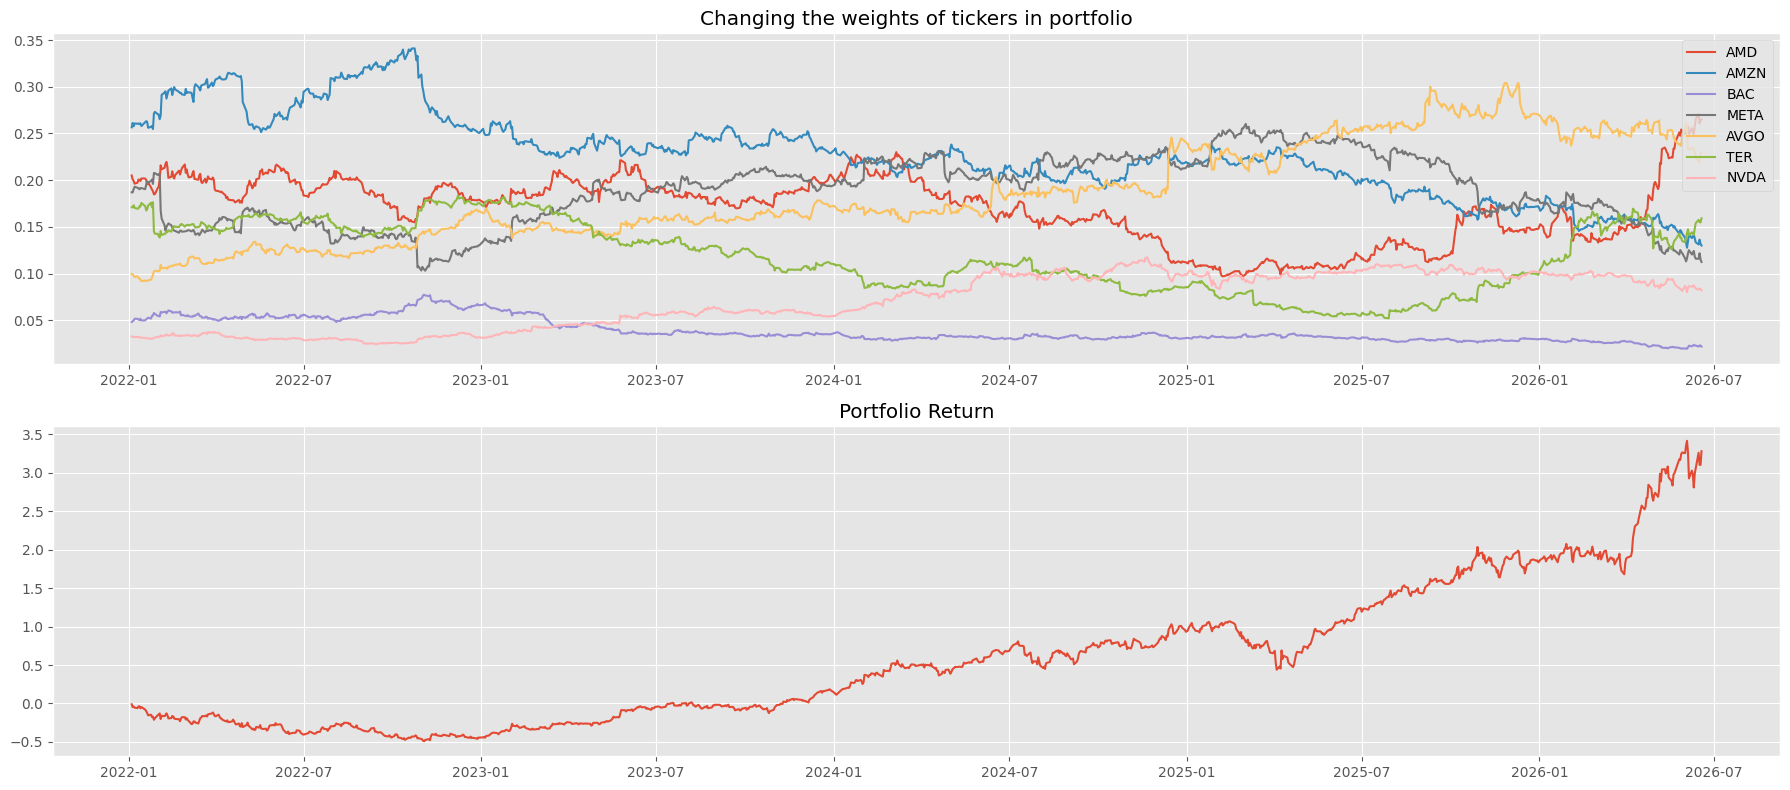

In [14]:
fig, axs = plt.subplots(2, 1, figsize=(18, 8))

axs[0].plot(weights, label=tickers)
axs[0].set_title('Changing the weights of tickers in portfolio')
axs[0].legend()

axs[1].plot(portfolio_cummulative)
axs[1].set_title('Portfolio Return')

plt.tight_layout()

## Portfolio risk

$
\sigma_p = \sqrt{w^T\Sigma w}
$

In [15]:
w = weights.iloc[-1].values
cov_matrix = returns.cov() * 252

portfolio_variance = w.T @ cov_matrix @ w
portfolio_risk = np.sqrt(portfolio_variance)

portfolio_risk

np.float64(0.38288191501724583)